In [4]:
%pip install arm-pyart s3fs
import gzip, io
import fsspec, pyart
import matplotlib.pyplot as plt

# --- 1. connect to the public NEXRAD archive (anonymous) ---
fs = fsspec.filesystem("s3", anon=True)
folder = "unidata-nexrad-level2/2023/08/15/KMLB/"

# --- 2. (optional) browse the folder to pick a ~05 UTC volume ---
for f in fs.ls(folder):
    print(f.split("/")[-1])


Note: you may need to restart the kernel to use updated packages.
KMLB20230815_000244_V06
KMLB20230815_000749_V06
KMLB20230815_001317_V06
KMLB20230815_001845_V06
KMLB20230815_002413_V06
KMLB20230815_003123_V06
KMLB20230815_003728_V06
KMLB20230815_004334_V06
KMLB20230815_004939_V06
KMLB20230815_005544_V06
KMLB20230815_005544_V06_MDM
KMLB20230815_010149_V06
KMLB20230815_010753_V06
KMLB20230815_011358_V06
KMLB20230815_011949_V06
KMLB20230815_012540_V06
KMLB20230815_013129_V06
KMLB20230815_013704_V06
KMLB20230815_014239_V06
KMLB20230815_014714_V06
KMLB20230815_015149_V06
KMLB20230815_015624_V06
KMLB20230815_015624_V06_MDM
KMLB20230815_020100_V06
KMLB20230815_020536_V06
KMLB20230815_021010_V06
KMLB20230815_021445_V06
KMLB20230815_021920_V06
KMLB20230815_022355_V06
KMLB20230815_022831_V06
KMLB20230815_023306_V06
KMLB20230815_023741_V06
KMLB20230815_024217_V06
KMLB20230815_024651_V06
KMLB20230815_025126_V06
KMLB20230815_025601_V06
KMLB20230815_025601_V06_MDM
KMLB20230815_030037_V06
KMLB202308

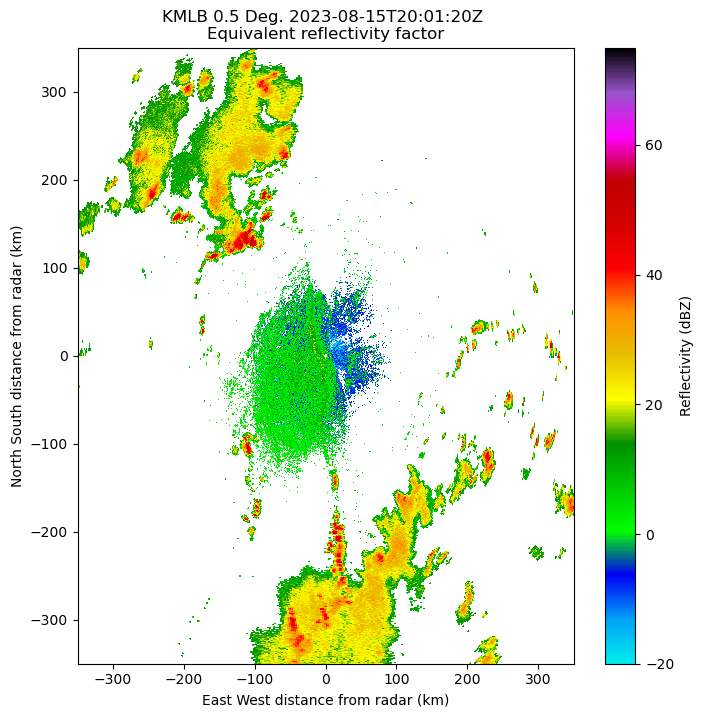

In [7]:
# --- 3. read one volume, unzipping the outer gzip ourselves ---
key = folder + "KMLB20230815_200120_V06"   # <- set to your chosen file
with fs.open(key, "rb") as fh:
    raw = fh.read()
if raw[:2] == b"\x1f\x8b":                     # gzip magic bytes
    raw = gzip.decompress(raw)
radar = pyart.io.read_nexrad_archive(io.BytesIO(raw))

# --- 4. plot the 0.5° reflectivity PPI out to ~230 km ---
disp = pyart.graph.RadarDisplay(radar)
fig = plt.figure(figsize=(8, 8))
disp.plot("reflectivity", sweep=0,
          vmin=-20, vmax=75,
          cmap="NWSRef",
          colorbar_label="Reflectivity (dBZ)")
disp.set_limits(xlim=(-350, 350), ylim=(-350, 350))

# --- 5. save for embedding in the notebook ---
plt.savefig("block2_image1.png", dpi=130, bbox_inches="tight")
plt.show()